In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from utils import tabulate_neatly
import SPDE
import yaml
import time

# Flags

Runs experiment for those which are set to true (~10min/experiment)

In [2]:
HEAT = True
NAGUMO = True
ALLEN_CAHN = True

DRIFT = True
DIFFUSION = True

GENERATE_PREDICTION_DATA = True
GENERATE_TRAINING_DATA = True
RUN_LASSO = True
RUN_SINDY = True

LEGENDRE_POLYNOMIALS = True

ALGORITHMS = {"Lasso": RUN_LASSO, "SINDy": RUN_SINDY}
IDENTIFICATION_TASKS = {"Drift": DRIFT, "Diffusion": DIFFUSION}

#### Generate Data

In [3]:
import DataGenerator as dg

experimentKeys = {"Heat": HEAT,
 "Nagumo": NAGUMO,
 "Allen_Cahn": ALLEN_CAHN}

for key, value in experimentKeys.items():
    if value and GENERATE_TRAINING_DATA:
        dg.generateData(key)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number:  1900
uStorage shape: (64, 501, 2000)
xdt shape: (64, 500)
xdiff shape: (64, 500)
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number: 

#### Mean of Dictionaries

In [4]:


with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

space = yamlParameters["common"]["x_end"] - yamlParameters["common"]["x_start"]
timeRange = yamlParameters["common"]["t_end"] - yamlParameters["common"]["t_start"]
timeSteps = yamlParameters["common"]["timesteps"]
spacePoints = yamlParameters["common"]["J"]
isPeriodic = yamlParameters["common"]["periodic"]

problemDictionaries = {}
problemDescriptions = {}

for key, value in experimentKeys.items():
    if value:   
        U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
        dx = space/(U.shape[0])
        dt = timeRange/(U.shape[1]-1)
        Dictt = []
        for i in range(U.shape[2]):
            if i%100==0:
                print(i)
            U_t,Di,description = SPDE.build_linear_system(U[:,:-1,i], dt, dx, D = 5, P = 6 ,periodic=isPeriodic, legendre=LEGENDRE_POLYNOMIALS)
            Dictt.append(Di)
        Dictt = np.mean(np.array(Dictt), axis=0)
        problemDictionaries[key] = Dictt
        problemDescriptions[key] = description

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


# Lasso and SINDy

In [5]:
# the following will be bad swe

Xi_drift_true = {
       "Heat": [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., yamlParameters["heat"]["correct"]["epsilon"], 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       "Nagumo": [0., yamlParameters["nagumo"]["correct"]["u_coeff"], yamlParameters["nagumo"]["correct"]["u2_coeff"], yamlParameters["nagumo"]["correct"]["u3_coeff"]] + [0.]*10 + [yamlParameters["nagumo"]["correct"]["epsilon"]] + [0.]*27, # i do NOT have faith in this
        "Allen_Cahn": [0., yamlParameters["allen_cahn"]["correct"]["u_coeff"], 0., yamlParameters["allen_cahn"]["correct"]["u3_coeff"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., yamlParameters["allen_cahn"]["correct"]["epsilon"], 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.]
}

Xi_diffusion_true = {
       "Heat": [yamlParameters["heat"]["correct"]["sigma"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
        "Nagumo": [yamlParameters["nagumo"]["correct"]["sigma"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
        "Allen_Cahn": [yamlParameters["allen_cahn"]["correct"]["sigma"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.]
}


In [6]:
results = []

for identificationTask, value in IDENTIFICATION_TASKS.items():
    if value:
        for algorithm, value in ALGORITHMS.items():
            if value:
                for problem, dictionary in problemDictionaries.items():
                    if identificationTask == "Drift":
                        target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
                    elif identificationTask == "Diffusion":
                        target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')
                    np.random.seed(0)
                    
                    target = target.reshape(1,-1, order='F')
                    start_time = time.time()
                    lam = yamlParameters["common"][f"{algorithm.lower()}_{identificationTask.lower()}_lambda"]
                    if algorithm == "Lasso":
                        Xi_coeffs = SPDE.Lasso(dictionary, target, lam)
                    elif algorithm == "SINDy":
                        Xi_coeffs = SPDE.sindy(lam,dictionary,target)
                    end_time = time.time()

                    targetCoeffs = Xi_drift_true[problem] if identificationTask == "Drift" else Xi_diffusion_true[problem]

                    l2_error = np.linalg.norm(targetCoeffs - Xi_coeffs.reshape(-1))

                    corr_ind = []
                    for i in range(len(targetCoeffs)):
                        if targetCoeffs[i] != 0:
                            corr_ind.append(i)
                    fp = 0
                    for i in range(len(targetCoeffs)):
                        if i in corr_ind:
                            pass
                        else:
                            if Xi_coeffs.reshape(-1)[i] != 0:
                                fp += 1

                    total_negatives = len(targetCoeffs) - len(corr_ind)
                    fpr = (fp / total_negatives) * 100 # expect legendre to mess up here in terms of coeffs, due to scaling + nonstandard polynomial

                    results.append([f"{problem} | {identificationTask}", algorithm, round(l2_error, 4), round(fpr, 2), round(end_time - start_time, 4)])

tabulate_neatly(results, headers=["Problem", "Algorithm", "L2 Error", "FPR (%)", "Time (s)"], title="Identification Results")

Identification Results

Problem,Algorithm,L2 Error,FPR (%),Time (s)
Heat | Drift,Lasso,0.8298,68.29,2.1191
Nagumo | Drift,Lasso,1.6002,50,1.8518
Allen_Cahn | Drift,Lasso,1.2207,41.03,1.7479
Heat | Drift,SINDy,0.0168,0,0.1183
Nagumo | Drift,SINDy,2.7531,15.79,0.1858
Allen_Cahn | Drift,SINDy,2.9334,12.82,0.1489
Heat | Diffusion,Lasso,0.9021,90.24,1.7908
Nagumo | Diffusion,Lasso,0.1812,48.78,1.7348
Allen_Cahn | Diffusion,Lasso,0.2576,70.73,1.6677
Heat | Diffusion,SINDy,0.0207,0,0.0866


# Variational Bayes

NOTE: Fixed, using zero-initialisation

In [ ]:
results_vb = []
problemDS = {}
results_vb_variances = []
DIAGNOSTICS = False

for identificationTask, value in IDENTIFICATION_TASKS.items():
    if value:
        for problem, dictionary in problemDictionaries.items():

            if identificationTask == "Drift":
                target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
            elif identificationTask == "Diffusion":
                target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')

            y = target.reshape(-1, order='F')

            np.random.seed(30)
            initz0 = np.ones(dictionary.shape[1])

            tol = 0.000001
            verbosity = True

             # -------------------------------------------------
            # DIAGNOSTICS: Conditioning (TBD) + redundancy
            # -------------------------------------------------   
            if DIAGNOSTICS:
                u, s, vt = np.linalg.svd(dictionary, full_matrices=False)

                condNum = s[0] / s[-1] # if large, suggests that many features are linearly dependent or explain stff in similar way
                effectiveRank = np.sum(s > 1e-10 * s[0])   # comparative - sort of like an estimation for rank where singular valuues are non-negligible          

                corr = np.corrcoef(dictionary[:, 1:].T)  # exclude intercept
                upper = np.triu(np.abs(corr), 1)
                maxCorr = np.nanmax(upper)
                
                meanCorr = np.mean(upper[upper > 0])
                nHighCorr = np.sum(upper > 0.99)

                colStds = np.std(dictionary, axis=0)
                nearConstant = np.sum(colStds < 1e-10)
                rows, cols = np.where(upper > 0.99)
                highlyCorrelatedPairs = list(zip(rows, cols))
                desc = problemDescriptions[problem][1:]  # skip intercept

                if identificationTask == "Drift": # just do once

                    plt.figure(figsize=(10, 8))
                    plt.plot(s, 'o-')
                    plt.title(f"Singular Values of Dictionary ({problem} | {identificationTask})")
                    plt.xlabel("Index")
                    plt.ylabel("Singular Value")
                    plt.show()

                    print(f"\n--- Diagnostics ({problem} | {identificationTask}) ---")
                    
                    print(f"\n--- Conditioning diagnostics ({problem} | {identificationTask}) ---")
                    print(f"Condition number (SVD): {condNum:.2e}")
                    print(f"Effective rank: {effectiveRank} / {dictionary.shape[1]}")
                    print(f"Max |corr|: {maxCorr:.4f}")
                    print(f"Mean |corr| (nonzero): {meanCorr:.4f}")
                    print(f"No. highly correlated pairs (>0.99): {nHighCorr}")
                    for pair in highlyCorrelatedPairs:
                        print(f"  - {desc[pair[0]]} and {desc[pair[1]]} (corr: {corr[pair[0], pair[1]]:.4f})")
                    print(f"Near-constant columns: {nearConstant}")
                

            # -------------------------------------------------
            # VB inference
            # -------------------------------------------------
            start_time = time.time()

            DS = SPDE.Variational_Bayes_Code(
                dictionary,
                y,
                initz0,
                tol,
                verbosity,
                p0=0.1,
                vs=100
            )

            problemDS.setdefault(problem, {})[identificationTask] = DS
            end_time = time.time()

            for i in range(dictionary.shape[1]):
                if abs(DS['wmean'][i]) <= 0.01:
                    DS['zmean'][i] = 0
                    DS['wmean'][i] = 0

            targetCoeffs = (
                Xi_drift_true[problem]
                if identificationTask == "Drift"
                else Xi_diffusion_true[problem]
            )

            l2_error_vb = np.linalg.norm(targetCoeffs - DS['wmean'])

            corr_ind = []
            for i in range(len(targetCoeffs)):
                if targetCoeffs[i] != 0:
                    corr_ind.append(i)

            fp_vb = 0
            for i in range(len(targetCoeffs)):
                if i in corr_ind:
                    pass
                else:
                    if DS['wmean'][i] != 0:
                        fp_vb += 1

            total_negatives = len(targetCoeffs) - len(corr_ind)
            fpr_vb = (fp_vb / total_negatives) * 100

            results_vb.append([
                f"{problem} | {identificationTask}",
                round(l2_error_vb, 4),
                round(fpr_vb, 2),
                round(end_time - start_time, 4)
            ])

            # -------------------------------------------------
            # variance table - only for discovered terms (PIP > 0.5)
            # -------------------------------------------------
            description = problemDescriptions[problem]
            variances = np.diag(DS['wCOV'])

            for i in range(len(DS['zmean'])):
                if DS['zmean'][i] > 0.5:
                    label = description[i] if description[i] != '' else '1'
                    results_vb_variances.append([
                        f"{problem} | {identificationTask}",
                        label,
                        round(float(DS['wmean'][i]), 4),
                        round(float(variances[i]), 6)
                    ])

tabulate_neatly(
    results_vb,
    headers=["Problem", "L2 Error", "FPR (%)", "Time (s)"],
    title="Variational Bayes Drift Results"
)

tabulate_neatly(
    results_vb_variances,
    headers=["Problem", "Term", "Mean", "Variance"],
    title="Variational Bayes Discovered Coefficients"
)

Iteration = 0  log(Likelihood) = -5294.331932766796
Iteration = 1  log(Likelihood) = -22680.845276320324
Iteration = 2  log(Likelihood) = -22672.801126049726
Iteration = 3  log(Likelihood) = -22670.096372651704
Iteration = 4  log(Likelihood) = -22662.429570826756
Iteration = 5  log(Likelihood) = -22645.8073831032
Iteration = 6  log(Likelihood) = -22641.108429176318
Iteration = 7  log(Likelihood) = -22641.106463427805
Iteration = 8  log(Likelihood) = -22641.106144836995
Iteration = 9  log(Likelihood) = -22641.106084726704
Iteration = 10  log(Likelihood) = -22641.106073326795
Iteration = 11  log(Likelihood) = -22641.106071143793
Iteration = 12  log(Likelihood) = -22641.106070721595
Iteration = 0  log(Likelihood) = -21407.677803581264
Iteration = 1  log(Likelihood) = -22747.213908930014
Iteration = 2  log(Likelihood) = -22703.17946957199
Iteration = 3  log(Likelihood) = -22680.471882589824
Iteration = 4  log(Likelihood) = -22670.126272012774
Iteration = 5  log(Likelihood) = -22667.2840414

c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\SPDE.py:403: UserWarning: s turned out be less than 0. Taking absolute value
  warnings.warn("s turned out be less than 0. Taking absolute value")


Iteration = 0  log(Likelihood) = 40215.41830614319
Iteration = 1  log(Likelihood) = 65330.25601411399
Iteration = 2  log(Likelihood) = 65376.497154031815
Iteration = 3  log(Likelihood) = 65376.48834831444
OOPS!  log(like) decreasing!!
Iteration = 4  log(Likelihood) = 65376.48697777595
OOPS!  log(like) decreasing!!
Iteration = 5  log(Likelihood) = 65376.48680149652
OOPS!  log(like) decreasing!!
Iteration = 6  log(Likelihood) = 65376.48677733257
OOPS!  log(like) decreasing!!
Iteration = 7  log(Likelihood) = 65376.48677390974
OOPS!  log(like) decreasing!!
Iteration = 8  log(Likelihood) = 65376.486773419914
OOPS!  log(like) decreasing!!
Iteration = 9  log(Likelihood) = 65376.486773342986
OOPS!  log(like) decreasing!!
Iteration = 10  log(Likelihood) = 65376.48677333302
OOPS!  log(like) decreasing!!
Iteration = 11  log(Likelihood) = 65376.486773326746
OOPS!  log(like) decreasing!!
Iteration = 12  log(Likelihood) = 65376.486773330405
Iteration = 0  log(Likelihood) = 65544.38370922097
Iteratio

Variational Bayes Drift Results

Problem,L2 Error,FPR (%),Time (s)
Heat | Drift,0.4347,29.27,5.2714
Nagumo | Drift,1.7736,26.32,32.0502
Allen_Cahn | Drift,1.5099,20.51,8.8335
Heat | Diffusion,0.1939,26.83,5.0318
Nagumo | Diffusion,0.0448,2.44,2.6296
Allen_Cahn | Diffusion,0.0375,4.88,5.1318


Variational Bayes Discovered Coefficients

Problem,Term,Mean,Variance
Heat | Drift,P1(u),0.0279,0.004245
Heat | Drift,P4(u),-0.0166,0.013614
Heat | Drift,P6(u),0.0669,0.018879
Heat | Drift,P1(u)u_x,0.3178,0.083179
Heat | Drift,P3(u)u_x,0.2367,0.086493
Heat | Drift,P0(u)u_xx,1.0004,0.000962
Heat | Drift,P1(u)u_xx,-0.0445,0.001833
Heat | Drift,P3(u)u_xx,-0.0999,0.003405
Heat | Drift,P5(u)u_xx,-0.0873,0.017125
Heat | Drift,P3(u)u_xxx,-0.0792,0.003988


### Plots

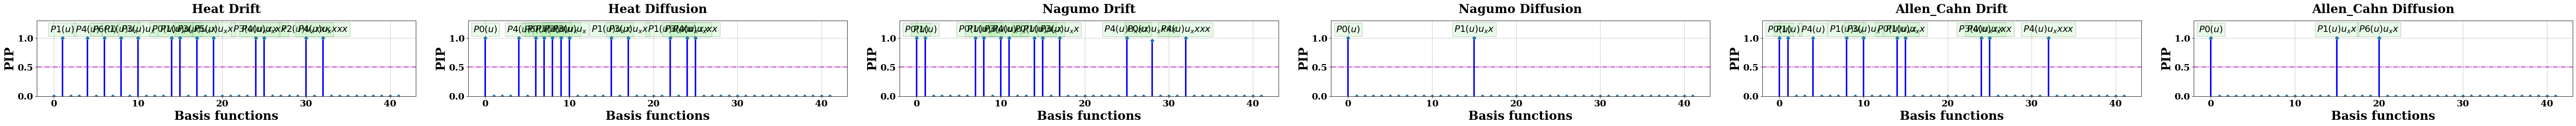

In [8]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 24

fig, axes = plt.subplots(1, len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), figsize=(12 * len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), 4))
axes = np.atleast_1d(axes)  # ensures axes is always an array even with 1 subplot

ax_idx = 0
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        ax = axes[ax_idx]
        ax_idx += 1
        xr = np.array(range(len(DS['zmean'])))

        ax.vlines(xr, 0, DS['zmean'], colors='blue', linewidth=3.0)
        ax.plot(xr, DS['zmean'], 'C0D', markersize=5)
        ax.axhline(y=0.5, color='m', linestyle='-.')

        # annotate discovered terms with PIP > 0.5
        description = problemDescriptions[problem]
        for i, pip in enumerate(DS['zmean']):
            if pip > 0.5:
                label = f"${description[i]}$" if description[i] != '' else '$1$'
                ax.text(i, 1.1, label, bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=18, ha='center')

        ax.set_xlabel('Basis functions', fontweight='bold', fontsize=24)
        ax.set_ylabel('PIP', fontweight='bold', fontsize=24)
        ax.set_title(f'{problem} {identificationTask}', fontweight='bold', fontsize=24, pad=15)
        ax.grid(color='gray', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, 1.3)
        ax.tick_params(axis='both', labelsize=18)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

### Write Coeffs out to yaml

In [9]:
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        disc = yamlParameters[problem.lower()]["discovered"]
        variances = np.diag(DS['wCOV'])
        
        # map description labels to discovered values and variances
        for i in range(len(DS['zmean'])):
            if DS['zmean'][i] > 0.5:
                description = problemDescriptions[problem]
                label = description[i] if description[i] != '' else '1'
                mean_val = round(float(DS['wmean'][i]), 6)
                var_val  = round(float(variances[i]), 8)
                
                #clean this up it looks terrible - maybe use a dictionary to map labels to yaml keys?
                #probably retrieve how this is done from SPDE.py and use the same mapping here to ensure consistency
                label_to_yaml = {
                    'u_{xx}': ('epsilon', 'epsilon_variance'),
                    '1': ('sigma_squared', 'sigma_squared_variance'),
                    'u': ('u_coeff', 'u_coeff_variance'),
                    'u^2': ('u2_coeff', 'u2_coeff_variance'),
                    'u^3': ('u3_coeff', 'u3_coeff_variance')
                }
                
                if label in label_to_yaml:
                    yaml_key, yaml_variance_key = label_to_yaml[label]
                    disc[yaml_key] = mean_val
                    disc[yaml_variance_key] = var_val

with open("parameters.yaml", "w") as f:
    yaml.dump(yamlParameters, f, default_flow_style=False, sort_keys=False)

### Collinearity Analysis

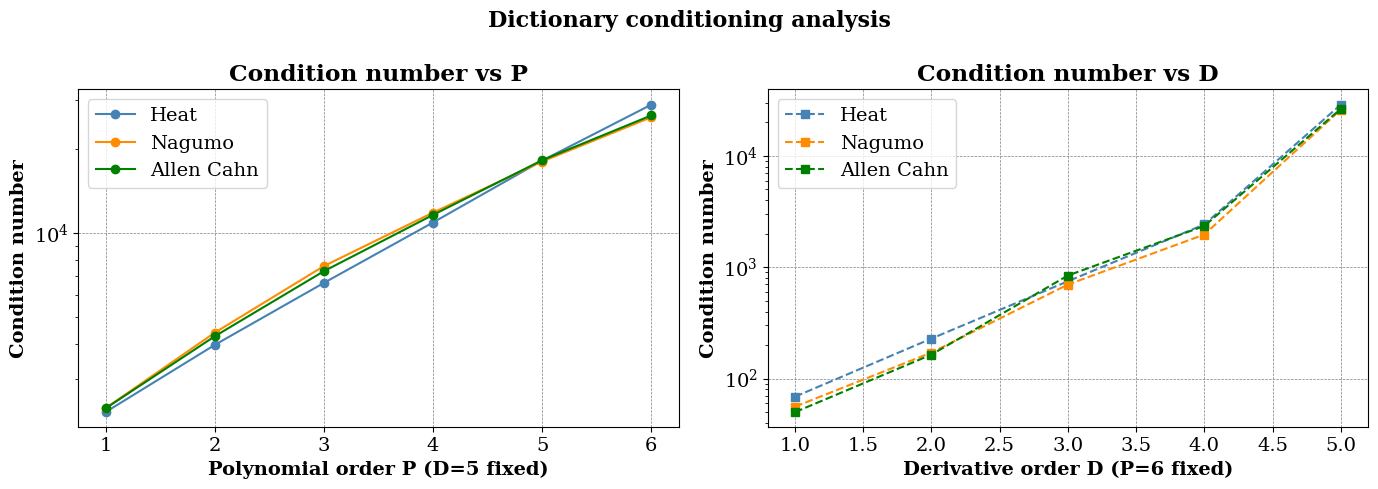

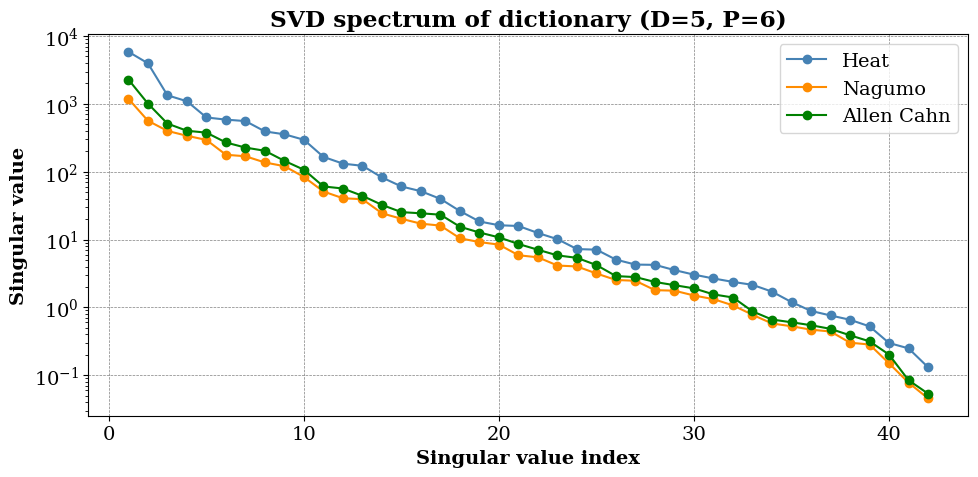


=== Highly correlated pairs (|corr| > 0.99) ===

Heat:
  None

Nagumo:
  P3(u)u_xx vs P3(u)u_xxxx: -0.9906
  P4(u)u_xx vs P4(u)u_xxxx: -0.9942
  P5(u)u_xx vs P5(u)u_xxxx: -0.9959
  P6(u)u_xx vs P6(u)u_xxxx: -0.9916

Allen_Cahn:
  P1(u)u_x vs P3(u)u_x: -0.9927
  P4(u)u_xx vs P4(u)u_xxxx: -0.9928
  P5(u)u_xx vs P5(u)u_xxxx: -0.9919


In [10]:
### Beware - a lot of repeated code

plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 14

colors = {'Heat': 'steelblue', 'Nagumo': 'darkorange', 'Allen_Cahn': 'green'}

# --- Plot 1: Condition number vs P and D ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    U = np.load(f'data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy')
    dx = space / U.shape[0]
    dt = timeRange / (U.shape[1] - 1)
    # use first sample only for speed
    u_sample = U[:, :-1, 0]

    # vary P, fix D=5
    cond_vs_P = []
    for P in range(1, 7):
        _, Di, _ = SPDE.build_linear_system(u_sample, dt, dx, D=5, P=P, periodic=isPeriodic, legendre=LEGENDRE_POLYNOMIALS)
        cond_vs_P.append(np.linalg.cond(Di))

    # vary D, fix P=6
    cond_vs_D = []
    for D in range(1, 6):
        _, Di, _ = SPDE.build_linear_system(u_sample, dt, dx, D=D, P=6, periodic=isPeriodic, legendre=LEGENDRE_POLYNOMIALS)
        cond_vs_D.append(np.linalg.cond(Di))

    axes[0].semilogy(range(1, 7), cond_vs_P, 'o-', color=colors[problem], label=problem.replace('_', ' '))
    axes[1].semilogy(range(1, 6), cond_vs_D, 's--', color=colors[problem], label=problem.replace('_', ' '))

axes[0].set_xlabel('Polynomial order P (D=5 fixed)', fontweight='bold')
axes[0].set_ylabel('Condition number', fontweight='bold')
axes[0].set_title('Condition number vs P', fontweight='bold')
axes[0].legend()
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)

axes[1].set_xlabel('Derivative order D (P=6 fixed)', fontweight='bold')
axes[1].set_ylabel('Condition number', fontweight='bold')
axes[1].set_title('Condition number vs D', fontweight='bold')
axes[1].legend()
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('Dictionary conditioning analysis', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('worthwhileImages/conditioning_vs_PD.pdf', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: SVD spectrum, all three problems overlaid ---
fig, ax = plt.subplots(figsize=(10, 5))

for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    _, s, _ = np.linalg.svd(problemDictionaries[problem], full_matrices=False)
    ax.semilogy(range(1, len(s)+1), s, 'o-', color=colors[problem], 
                label=problem.replace('_', ' '))

ax.set_xlabel('Singular value index', fontweight='bold')
ax.set_ylabel('Singular value', fontweight='bold')
ax.set_title('SVD spectrum of dictionary (D=5, P=6)', fontweight='bold')
ax.legend()
ax.grid(color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('worthwhileImages/svd_spectrum.pdf', dpi=150, bbox_inches='tight')
plt.show()

# --- Table: highly correlated pairs ---
print("\n=== Highly correlated pairs (|corr| > 0.99) ===")
for problem in experimentKeys:
    if not experimentKeys[problem]:
        continue
    desc = problemDescriptions[problem][1:]  # skip intercept
    D_mat = problemDictionaries[problem][:, 1:]  # skip intercept column
    corr = np.corrcoef(D_mat.T)
    rows, cols = np.where(np.triu(np.abs(corr), 1) > 0.99)
    print(f"\n{problem}:")
    if len(rows) == 0:
        print("  None")
    for r, c in zip(rows, cols):
        print(f"  {desc[r]} vs {desc[c]}: {corr[r,c]:.4f}")
    
    """
    sort of what you'd expect -  since abs(u) remainsbetween 2 (per plots), even powers behave similary reulgint in high correlations
    we also have that for a smooth periodic function,  the second and fourth derivatives are negatively related - e.g., (sin x and -sin(x)) - recall that initla conditions are sinusoidal and we have periodic bcs
    as a result of fixing the discontinuity at the boundaries and having smooth periodic data, we end up with  pretty much every u_xx and u_xxxx being highly correlated. I guess this means that the sinusoidal effect doesn't really disappear?
    """

# Prediction

Generate data per discovered coefficients

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


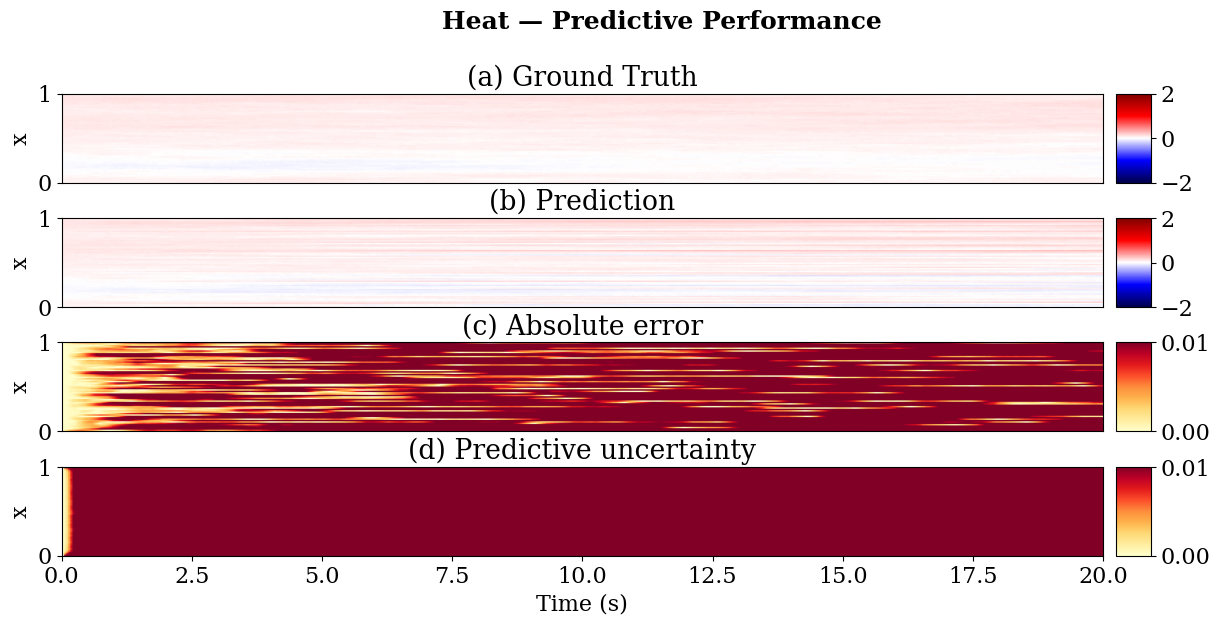

0.9400849425876732
correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


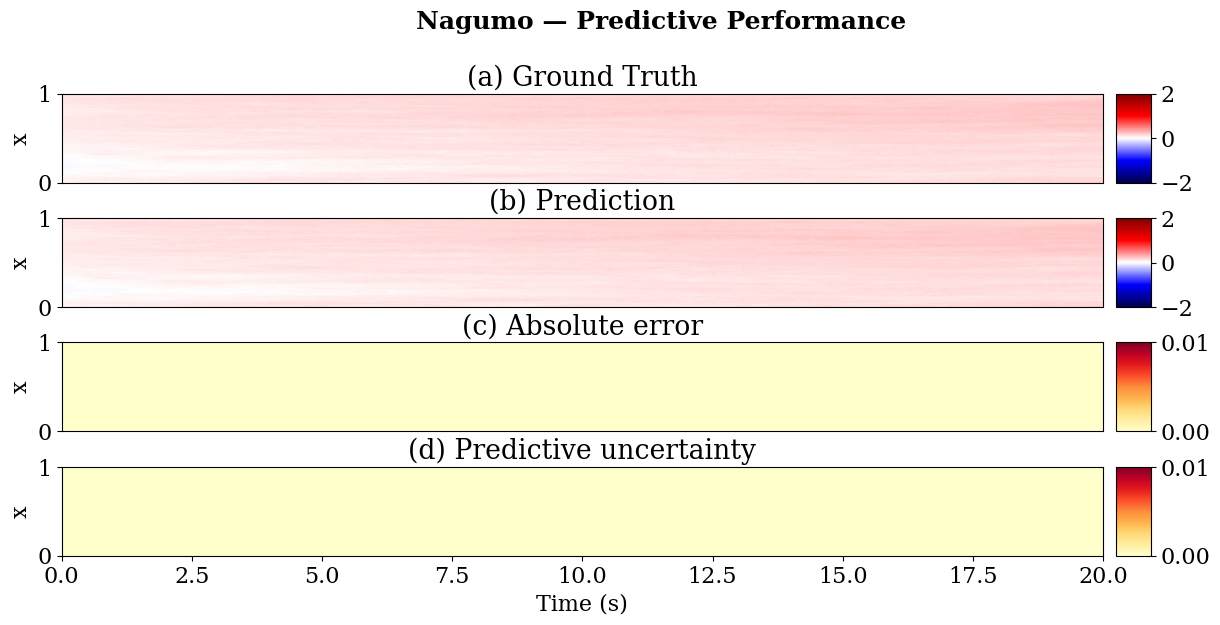

0.0
correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


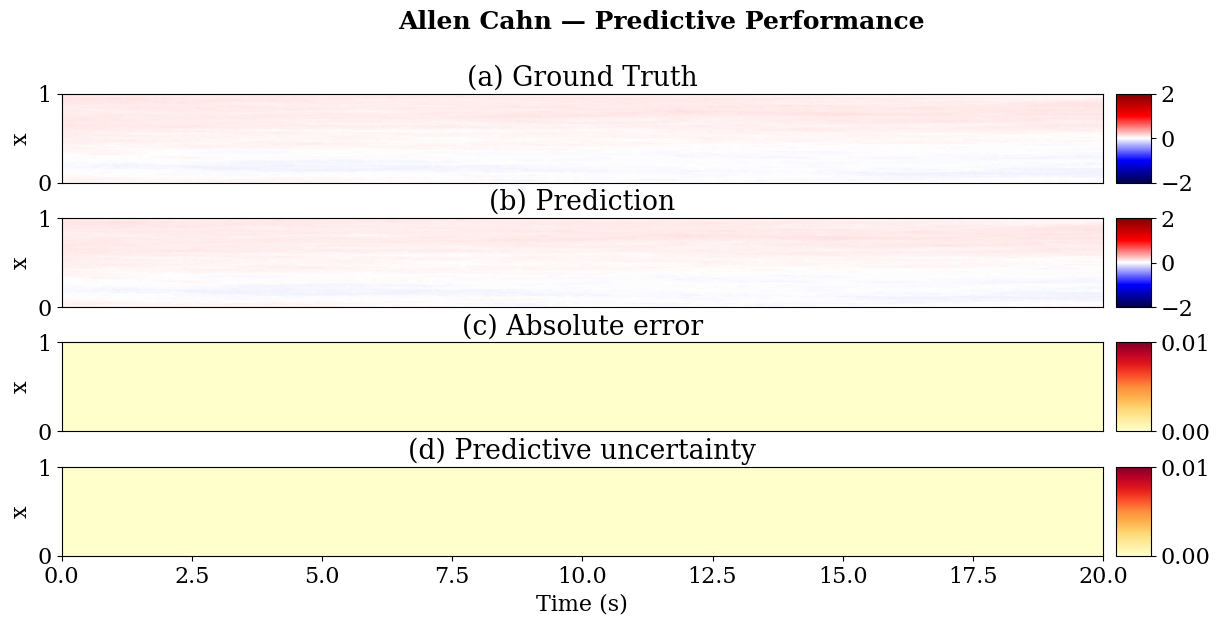

0.0


In [11]:
import PredictionDataGenerator

with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

for key, value in experimentKeys.items():
    if value:
        if GENERATE_PREDICTION_DATA:
            PredictionDataGenerator.generatePrediction(key)
        
        U3 = np.load(f'data/{key}_prediction_correct.npy')
        U4 = np.load(f'data/{key}_prediction_pred.npy')
        plt.rcParams['font.size'] = 16

        fig = plt.figure(figsize=(16,6))
        fig.subplots_adjust(wspace=1, hspace=0.4)
        
        solution_cmap = 'seismic'      # diverging for solution fields
        error_cmap = 'YlOrRd'          # sequential for error/uncertainty

        plt.subplot(4,1,1)
        uu = np.mean(U3, axis=2)
        plt.imshow(uu, cmap=solution_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x')
        plt.title('(a) Ground Truth')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,2)
        uu1 = np.mean(U4, axis=2)
        plt.imshow(uu1, cmap=solution_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x')
        plt.title('(b) Prediction')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,3)
        plt.imshow(np.abs(uu - uu1), cmap=error_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=0, vmax=0.01)
        plt.ylabel('x')
        plt.title('(c) Absolute error')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,4)
        plt.imshow(np.std(U3 - U4, axis=2), cmap=error_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=0, vmax=0.01)
        plt.xlabel('Time (s)')
        plt.ylabel('x')
        plt.title('(d) Predictive uncertainty')
        plt.colorbar(aspect=2.5, pad=0.01)

        fig.suptitle(f'{key.replace("_", " ").title()} — Predictive Performance', fontweight='bold', fontsize=18, y=1.02)

        plt.show()
        print(np.max(np.std(U3 - U4, axis=2)))
        fig.savefig(f'data/{key}_prediction.pdf', format='pdf', dpi=300, bbox_inches='tight')